# Import Libraries

In [61]:
# Import libraries
import numpy as np
import pandas as pd
import seaborn as sns
import  matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from imblearn.over_sampling import SMOTE




# import all models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

from sklearn.naive_bayes import GaussianNB
# from lightgbm import LGBMClassifier

# impot pipeline
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
# import metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report


In [62]:
import imblearn
print(imblearn.__version__)


0.14.1


# Load Dataset

In [63]:
# Load Data

df = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# Information about Dataset


In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


# Check Missing values

In [65]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

# Statistics summary 

In [66]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## 3. Fix Incorrect Zero Values

In [67]:
import warnings
warnings.filterwarnings('ignore')


cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in cols:
    df[col] = df[col].replace(0, np.nan)
    df[col].fillna(df[col].median(), inplace=True)

df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [68]:
df['Age'].min(), df['Age'].max()

(np.int64(21), np.int64(81))

## 4. Feature Engineering

In [69]:
df['BMI_Glucose'] = df['BMI'] * df['Glucose']
df['AgeGroup'] = pd.cut(df['Age'], bins=[20,30,40,50,60,85], labels=[1,2,3,4,5])
df['AgeGroup'] = df['AgeGroup'].astype('Int64')

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,BMI_Glucose,AgeGroup
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1,4972.8,3
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0,2261.0,2
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1,4263.9,2
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0,2500.9,1
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1,5904.7,2


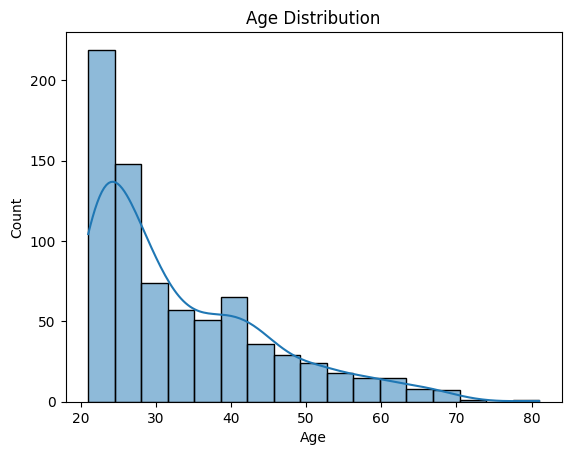

In [70]:
sns.histplot(df['Age'], kde=True)
plt.title('Age Distribution')
plt.show()

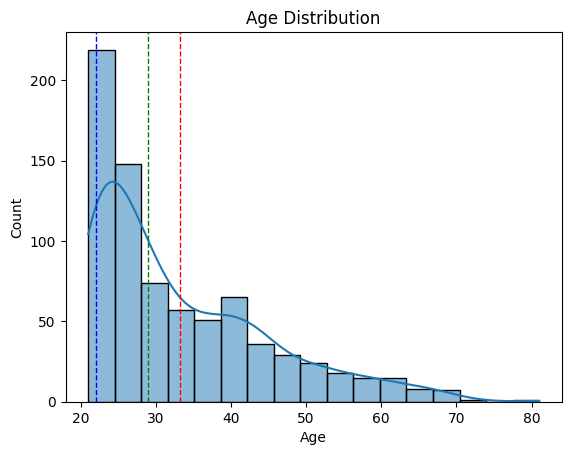

Mean: 33.240885416666664
Median: 29.0
Mode: 22


In [71]:
# plot mean, median and mode of the age column using sns
sns.histplot(df['Age'], kde=True)
plt.axvline(df['Age'].mean(), color='red', linestyle='dashed', linewidth=1)
plt.axvline(df['Age'].median(), color='green', linestyle='dashed', linewidth=1)
plt.axvline(df['Age'].mode()[0], color='blue', linestyle='dashed', linewidth=1)
plt.title('Age Distribution')
plt.show()
# Print the value of mean, median and mode of the age column
print(f'Mean: {df["Age"].mean()}')
print(f'Median: {df["Age"].median()}')
print(f'Mode: {df["Age"].mode()[0]}')


In [72]:
# Find the values count of the age column grouping by sex column

df.groupby('Outcome')['Age'].value_counts()

Outcome  Age
0        22     61
         21     58
         24     38
         25     34
         23     31
                ..
1        55      1
         57      1
         61      1
         67      1
         70      1
Name: count, Length: 96, dtype: int64

In [73]:
# Find the mean of all columns groupbt by outcome column
df.groupby('Outcome').mean()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,BMI_Glucose,AgeGroup
Outcome,,,,,,,,,,
0,3.298000,110.682000,70.920000,27.726000,127.792000,30.885600,0.429734,31.190000,3437.629200,1.656
1,4.865672,142.130597,75.123134,31.686567,164.701493,35.383582,0.550500,37.067164,5039.648507,2.212687


In [74]:
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

# **Visualization**

# Count Outcome 

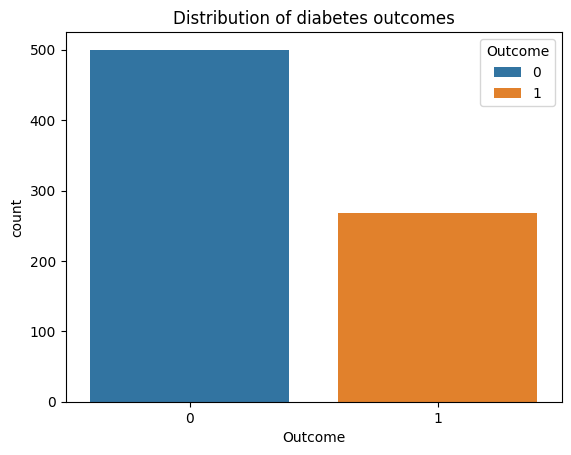

In [75]:
sns.countplot(data=df, x = 'Outcome', hue= 'Outcome')
plt.title('Distribution of diabetes outcomes')
plt.show()

# Correlation of the all columns using Heatmap plot

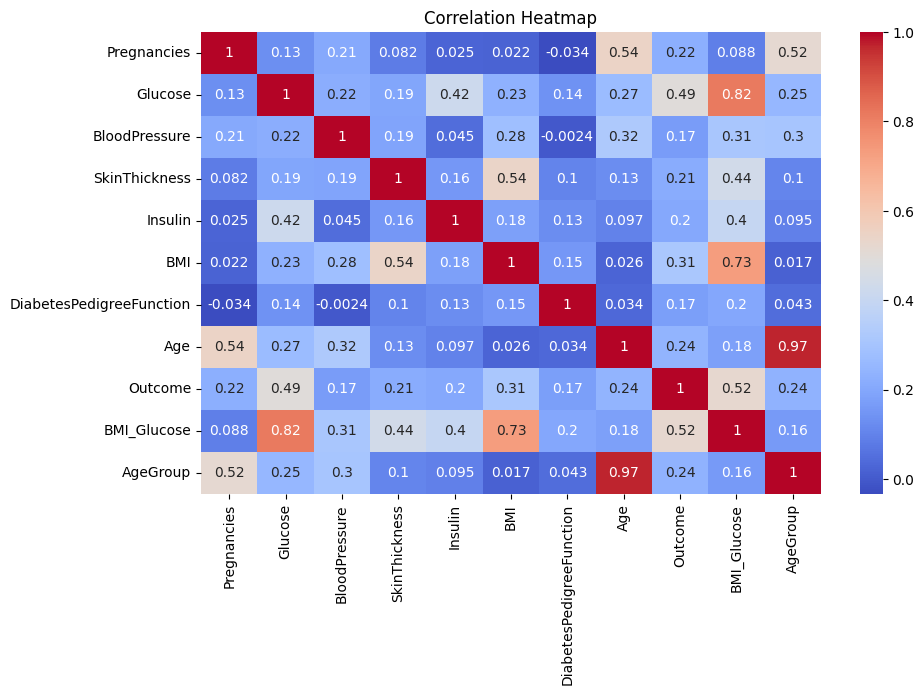

In [76]:

plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


# Pairplot

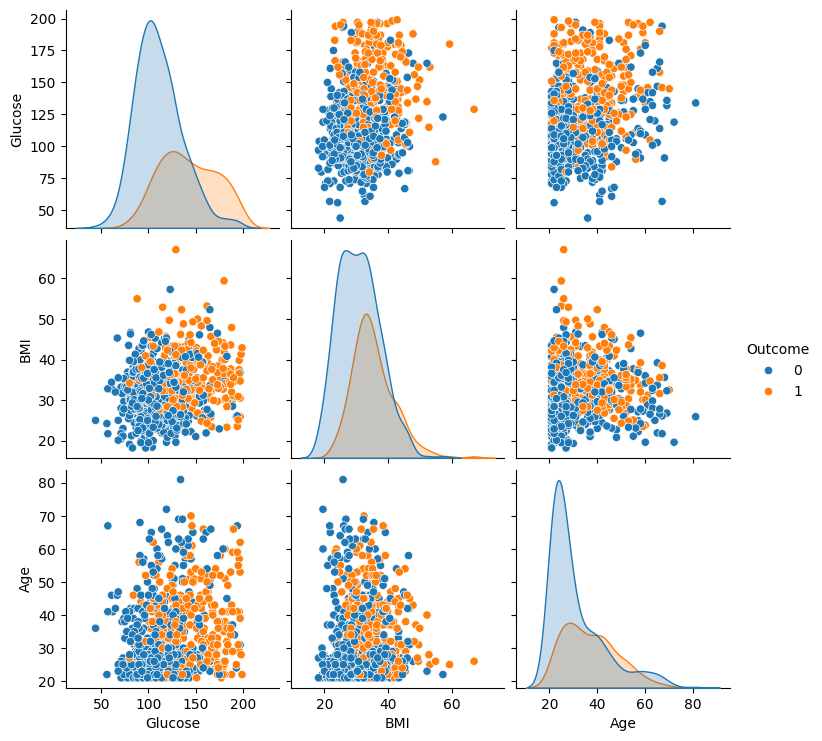

In [77]:
# Pairplot (subset)
sns.pairplot(df[['Glucose', 'BMI', 'Age', 'Outcome']], hue='Outcome')
plt.show()

# Split Data for Training and testing 

In [78]:
# separating the data and labels
X = df.drop(columns = 'Outcome', axis=1)
y = df['Outcome']

In [79]:
X = X.astype(float)


In [80]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Train_Test Data

In [81]:
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, train_size=0.8, random_state=42, stratify=y_resampled)

# Normalization(Scalling)

In [82]:
scalar = StandardScaler()
X_train = scalar.fit_transform(X_train)
X_test = scalar.fit_transform(X_test)

print(X_train)
print('--------------------')
print(X_test)

[[-0.4208907   1.39224144  0.06610558 ... -0.27143457  1.05899469
   0.04836592]
 [-1.23935757  0.35568891  0.93394543 ...  2.20645354 -0.32086827
   1.90019045]
 [ 0.60691142  1.1675705  -0.91815596 ...  1.40348646 -0.19259527
   0.97427819]
 ...
 [ 2.45318041  0.4531147   0.76557258 ...  2.11723498  0.82014132
   1.90019045]
 [-0.93164607 -0.55361848 -1.08652881 ... -1.18385193 -0.95505262
  -0.87754635]
 [ 2.76089191  1.03766945  3.45953823 ...  0.86817507  1.60048508
   0.97427819]]
--------------------
[[ 2.27071997 -1.12135515 -0.96115929 ...  0.87460593 -1.11827906
   0.92808657]
 [ 0.60260954  0.85682993  0.37682565 ... -0.60844219  1.84311533
  -0.85736983]
 [ 0.00370674  0.31938783  0.91039483 ... -0.33361408  0.00477443
  -0.85736983]
 ...
 [-1.19409884 -0.62903942  0.19896926 ... -0.8832703   0.37745331
  -0.85736983]
 [ 0.60260954 -0.24966852 -2.11316382 ... -0.05878598 -0.67817734
   0.08009034]
 [ 1.20151233 -0.21805428  1.08825122 ... -1.06648904 -0.55902682
  -0.857369

# Bulid Multiple Models

In [83]:
# Models

models = {
    "Random Forest": RandomForestClassifier(random_state= 42),
    "SVM": SVC(random_state=42),
    "xgboost": XGBClassifier(random_state =42) 
}

accuracy_scores = {}


In [84]:
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    accuracy_scores[name] = accuracy_score(y_test, pred)

accuracy_scores

{'Random Forest': 0.775, 'SVM': 0.825, 'xgboost': 0.82}

In [85]:
best_model = max(accuracy_scores, key=accuracy_scores.get)
best_accuracy = accuracy_scores[best_model]

print("Best Model:", best_model)
print("Accuracy:", best_accuracy)
import pickle
pickle.dump(best_model, open('diabetes.pkl', 'wb'))

Best Model: SVM
Accuracy: 0.825


In [86]:
final_model = models[best_model]
y_pred = final_model.predict(X_test)

cm = confusion_matrix(y_true=y_test, y_pred=y_pred)
cr = classification_report(y_true=y_test, y_pred=y_pred)
print(cm)
print(cr)

[[78 22]
 [13 87]]
              precision    recall  f1-score   support

           0       0.86      0.78      0.82       100
           1       0.80      0.87      0.83       100

    accuracy                           0.82       200
   macro avg       0.83      0.82      0.82       200
weighted avg       0.83      0.82      0.82       200



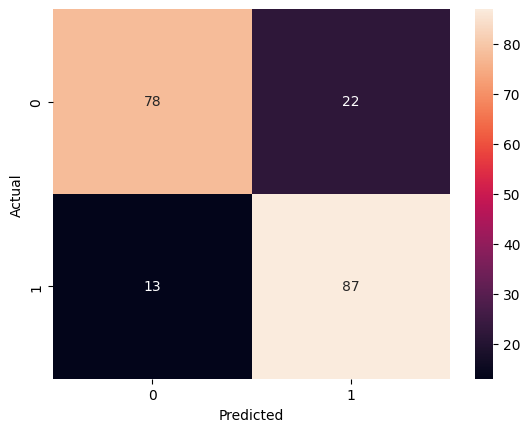

In [87]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [88]:
import warnings
warnings.filterwarnings('ignore')
input_data = (2, 48.0, 72.0,	35.0,	125.0, 33.6,	0.627,	30,	2272.8,	2)

# changing the input_data to numpy array
input_data_as_numpy_array = np.asarray(input_data)

# reshape the array as we are predicting for one instance
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)

# standardize the input data
std_data = scalar.transform(input_data_reshaped)
print(std_data)

prediction =model.predict(std_data)
print(prediction)

if (prediction[0] == 0):
  print('The person is not diabetic')
else:
  print('The person is diabetic')

[[-0.59519605 -2.49427966 -0.15674352  0.55811317 -0.32397576  0.06863296
   0.47702371 -0.33361408 -1.29774703  0.08009034]]
[0]
The person is not diabetic
